# 04b — Embedding net study: learned vs hand-crafted summary statistics

Tests whether the β bias observed in Sc2 (UA–β compensation) is structural
or an artefact of the hand-crafted 29-D summary statistics.

**Method**: Train a second SBI posterior using sbi's built-in `CNNEmbedding`
that learns summary statistics end-to-end from raw `(120, 4)` time-series
observations, bypassing the hand-crafted features entirely. Compare the
β posterior for Sc2 between the two approaches.

**If the embedding net also shows β bias ≈ 0.55–0.62** (true = 0.70),
the bias is confirmed structural — no summary statistic can resolve it
from closed-loop data. If the bias is reduced, the hand-crafted summaries
are losing information.

In [1]:
from __future__ import annotations

import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import gaussian_kde

from cstr_sbi.inference import sample_posterior, train_sbi_posterior
from cstr_sbi.metrics import PARAM_NAMES_2D, classify_fault, summarise_posterior
from cstr_sbi.physics import NOMINAL_CTRL, NOMINAL_INLET_CL
from cstr_sbi.priors import ALPHA_HIGH, ALPHA_LOW, BETA_HIGH, BETA_LOW, box_uniform_2d
from cstr_sbi.simulator import warm_start_ic
from cstr_sbi.physics import NOMINAL_PARAMS_CL

jax.config.update("jax_enable_x64", False)

ROOT    = Path.cwd().parent
DATA    = ROOT / "data" / "observations.npz"
RESULTS = ROOT / "results"
FIGS    = ROOT / "figures"

Y0_TRAIN = warm_start_ic(NOMINAL_PARAMS_CL, NOMINAL_INLET_CL, NOMINAL_CTRL)
prior = box_uniform_2d()

print(f"Prior: α=[{ALPHA_LOW}, {ALPHA_HIGH}]  β=[{BETA_LOW}, {BETA_HIGH}]")
print(f"Raw observation shape per window: (120, 4) = 480 scalars")

Prior: α=[0.4, 1.2]  β=[0.4, 1.2]
Raw observation shape per window: (120, 4) = 480 scalars


## 1. Load baseline (hand-crafted summaries) and observations

In [2]:
# 2026-08-13: load the MATCHED-PROTOCOL hand-crafted posterior (Stage 3
# Item 8 full validation), not the old fixed-warm-start production one --
# the comparison against the embedding net below must use the same
# (matched) protocol on both sides, or a residual bias difference could
# be a protocol artifact rather than a genuine representation-capacity result.
with open(RESULTS / "sbi_posterior_matched_protocol_n10000.pkl", "rb") as f:
    d_baseline = pickle.load(f)
posterior_baseline = d_baseline["posterior"]
print(f"Baseline posterior loaded: {d_baseline['metadata']}")

# Load observations
d = np.load(DATA, allow_pickle=False)
x_all = jnp.asarray(d["x"])          # (400, 120, 4)
t     = jnp.asarray(d["t"])          # (120,)
sid   = d["scenario_id"]
theta_all = d["theta"]

# Compute 29-D summaries for baseline evaluation
from cstr_sbi.summaries import compute_summary_statistics_batch
S_all = np.asarray(compute_summary_statistics_batch(x_all, t))

# Raw observations flattened for embedding-net evaluation
x_raw_all = np.asarray(x_all).reshape(x_all.shape[0], -1)  # (400, 480)

def pick_obs(sc_id, rep=0):
    mask = np.where(sid == sc_id)[0]
    idx = mask[rep]
    return S_all[idx], x_raw_all[idx], float(theta_all[idx, 2]), float(theta_all[idx, 3])

print(f"Observations: {x_all.shape}, summaries: {S_all.shape}, raw flat: {x_raw_all.shape}")

Baseline posterior loaded: {'n_simulations': 10000, 'density_estimator': 'nsf', 'hidden_features': 128, 'num_transforms': 5, 'training_batch_size': 256, 'max_num_epochs': 200, 'wall_time_s': 4731.370576166984}
Observations: (400, 120, 4), summaries: (400, 29), raw flat: (400, 480)


## 2. Train embedding-net posterior

Uses sbi's built-in `CNNEmbedding` with the raw `(120, 4)` time series.

In [3]:
from sbi.neural_nets.embedding_nets import CNNEmbedding

embedding_net = CNNEmbedding(
    input_shape=(120,),
    in_channels=4,
    out_channels_per_layer=[16, 32],
    num_conv_layers=2,
    num_linear_layers=2,
    num_linear_units=64,
    output_dim=20,
    kernel_size=5,
    pool_kernel_size=2,
)
print(f"CNNEmbedding: {sum(p.numel() for p in embedding_net.parameters())} parameters")
print(embedding_net)

EMB_PATH = RESULTS / "sbi_posterior_embedding_matched_protocol.pkl"  # 2026-08-13: matched-protocol retrain (Major Comment 7)

RUN_TRAINING = True

if RUN_TRAINING:
    print("\nTraining embedding-net posterior (10k sims, NSF, CNNEmbedding)...")
    posterior_emb, meta_emb = train_sbi_posterior(
        prior,
        n_simulations=10_000,
        density_estimator="nsf",
        hidden_features=128,
        num_transforms=5,
        training_batch_size=256,
        max_num_epochs=300,
        save_to=str(EMB_PATH),
        seed=0,
        y0=Y0_TRAIN,
        embedding_net=embedding_net,
        use_raw_obs=True,
        # 2026-08-13, Major Comment 7 / pending_manuscript_fixes.md Stage 3 Item 8:
        # this experiment (the CNN-embedding "irreducibility" check, main.tex
        # Sec 6.3.3) was confirmed by code inspection to share the identical
        # fixed-healthy-warm-start protocol bug as the hand-crafted-feature SBI
        # posterior. Retraining under the matched (scenario-specific warm-start)
        # protocol to test whether its "confirms irreducibility to within 1%"
        # claim survives the same correction that resolved ~99% of the
        # hand-crafted-feature SBI's beta bias.
        scenario_specific_warm_start=True,
    )
    print(f"Done. {meta_emb}")
else:
    with open(EMB_PATH, "rb") as f:
        d_emb = pickle.load(f)
    posterior_emb, meta_emb = d_emb["posterior"], d_emb["metadata"]
    print(f"Loaded cached embedding posterior: {meta_emb}")

CNNEmbedding: 61636 parameters
CNNEmbedding(
  (cnn_subnet): Sequential(
    (0): Conv1d(4, 16, kernel_size=(5,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(1,))
    (4): ReLU(inplace=True)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_subnet): FCEmbedding(
    (net): Sequential(
      (0): Linear(in_features=896, out_features=64, bias=True)
      (1): Identity()
      (2): ReLU()
      (3): Linear(in_features=64, out_features=20, bias=True)
      (4): ReLU()
    )
  )
)

Training embedding-net posterior (10k sims, NSF, CNNEmbedding)...


  0%|          | 0/10000 [00:00<?, ?it/s]

Training complete: 90 epochs, best val loss = -2.8607, wall time = 5089s
Done. {'n_simulations': 10000, 'density_estimator': 'nsf', 'hidden_features': 128, 'num_transforms': 5, 'training_batch_size': 256, 'max_num_epochs': 300, 'wall_time_s': 5089.224303750001}


## 3. Compare posteriors: Sc1, Sc2, Sc3

In [4]:
N_SAMPLES = 10_000
eval_scenarios = [
    (1, "Sc1 healthy",        1.00, 1.00),
    (2, "Sc2 fouling",        1.00, 0.70),
    (3, "Sc3 decay",          0.70, 1.00),
    (4, "Sc4 combined",       0.85, 0.85),
    (5, "Sc5 saturated",      1.00, 0.40),
]

results = []
for sc_id, sc_name, alpha_t, beta_t in eval_scenarios:
    obs_summary, obs_raw, _, _ = pick_obs(sc_id)
    true_params = np.array([alpha_t, beta_t])

    # Baseline (hand-crafted summaries)
    s_base = sample_posterior(posterior_baseline, obs_summary, n_samples=N_SAMPLES)
    m_base = summarise_posterior(s_base, true_params)

    # Embedding net (raw observations)
    s_emb = sample_posterior(posterior_emb, obs_raw, n_samples=N_SAMPLES)
    m_emb = summarise_posterior(s_emb, true_params)

    results.append(dict(
        sc_id=sc_id, sc_name=sc_name,
        alpha_true=alpha_t, beta_true=beta_t,
        base_alpha_mean=m_base["alpha"]["mean"],
        base_beta_mean=m_base["beta"]["mean"],
        base_beta_cov90=m_base["beta"]["coverage_90"],
        emb_alpha_mean=m_emb["alpha"]["mean"],
        emb_beta_mean=m_emb["beta"]["mean"],
        emb_beta_cov90=m_emb["beta"]["coverage_90"],
        samples_base=s_base,
        samples_emb=s_emb,
    ))
    print(f"{sc_name}:  baseline β={m_base['beta']['mean']:.3f}  "
          f"embedding β={m_emb['beta']['mean']:.3f}  (true={beta_t:.2f})")

import pandas as pd
df = pd.DataFrame([{k: v for k, v in r.items() if k != 'samples_base' and k != 'samples_emb'}
                   for r in results])
print("\n" + df.to_string(index=False))

/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(


Sc1 healthy:  baseline β=1.035  embedding β=1.024  (true=1.00)


Sc2 fouling:  baseline β=0.728  embedding β=0.696  (true=0.70)


Sc3 decay:  baseline β=1.073  embedding β=1.071  (true=1.00)


Sc4 combined:  baseline β=0.835  embedding β=0.846  (true=0.85)


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/src/cstr_sbi/inference.py:573: UserWarning: 61.8% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samples = posterior.sample(


Sc5 saturated:  baseline β=0.397  embedding β=0.470  (true=0.40)

 sc_id       sc_name  alpha_true  beta_true  base_alpha_mean  base_beta_mean  base_beta_cov90  emb_alpha_mean  emb_beta_mean  emb_beta_cov90
     1   Sc1 healthy        1.00       1.00         0.994320        1.034709             True        0.902247       1.024024            True
     2   Sc2 fouling        1.00       0.70         0.987832        0.727857            False        0.853224       0.695991            True
     3     Sc3 decay        0.70       1.00         0.701062        1.073475            False        0.904688       1.071057            True
     4  Sc4 combined        0.85       0.85         0.849518        0.835072             True        0.871364       0.846273            True
     5 Sc5 saturated        1.00       0.40         1.001140        0.397299             True        0.869610       0.469831           False


## 4. Marginal comparison figure

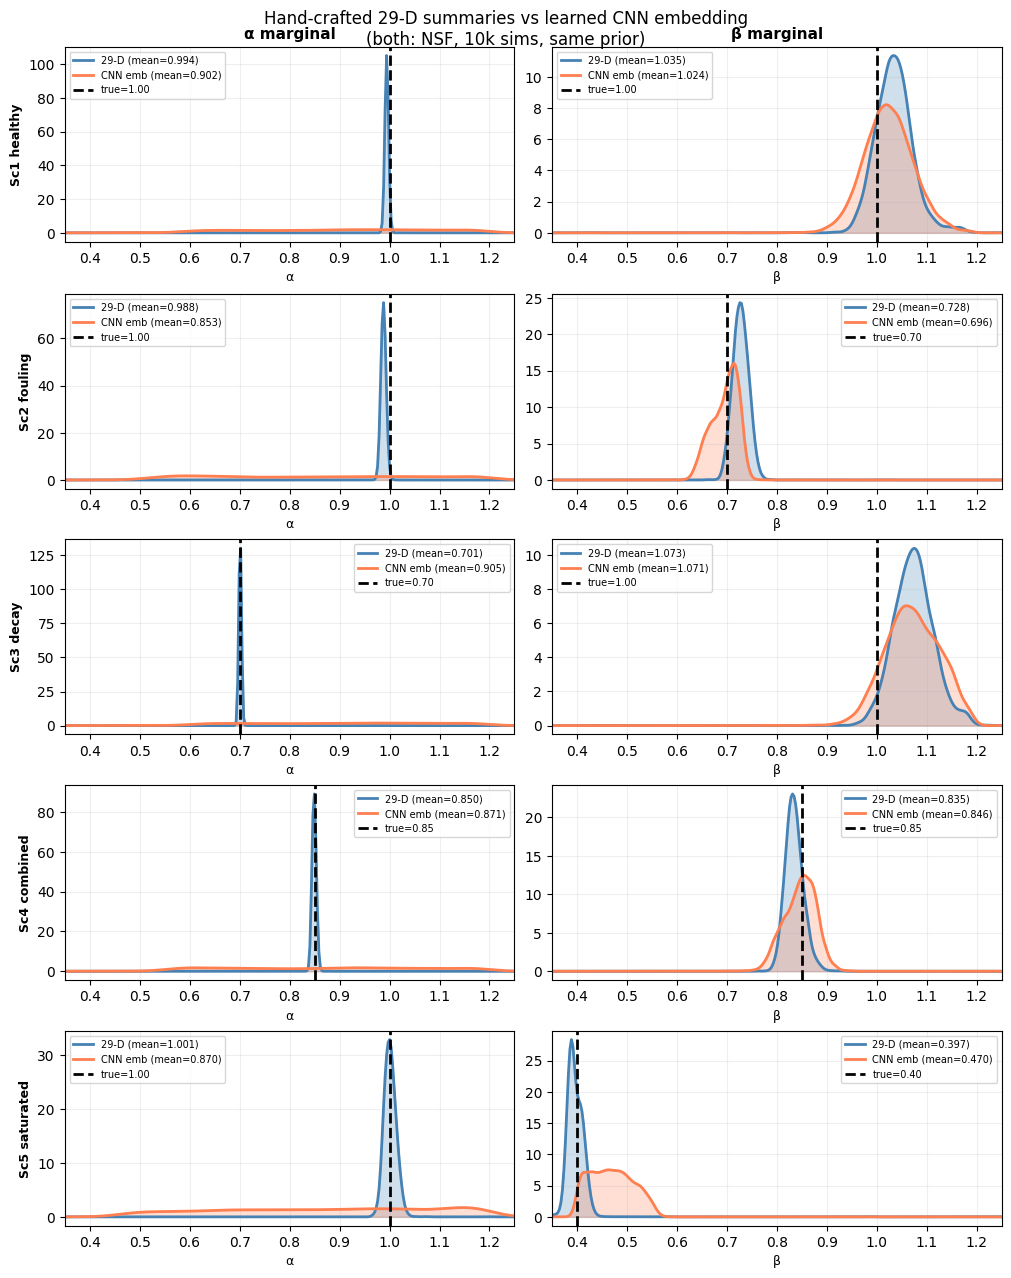

Saved 04b_embedding_vs_handcrafted.png


In [5]:
BASE_COLOR = "steelblue"
EMB_COLOR  = "coral"
TRUE_COLOR = "black"

n_sc = len(results)
fig, axes = plt.subplots(n_sc, 2, figsize=(10, 2.5 * n_sc), constrained_layout=True)

for row, r in enumerate(results):
    for col, (param, idx, true_val) in enumerate([
        ("α", 0, r["alpha_true"]),
        ("β", 1, r["beta_true"]),
    ]):
        ax = axes[row, col]
        v_base = r["samples_base"][:, idx]
        v_emb  = r["samples_emb"][:, idx]

        x_lo = max(ALPHA_LOW - 0.05, min(v_base.min(), v_emb.min(), true_val) - 0.05)
        x_hi = min(ALPHA_HIGH + 0.05, max(v_base.max(), v_emb.max(), true_val) + 0.05)
        x_grid = np.linspace(x_lo, x_hi, 300)

        kde_b = gaussian_kde(v_base)
        kde_e = gaussian_kde(v_emb)

        ax.fill_between(x_grid, kde_b(x_grid), alpha=0.25, color=BASE_COLOR)
        ax.plot(x_grid, kde_b(x_grid), color=BASE_COLOR, lw=2,
                label=f"29-D (mean={v_base.mean():.3f})")
        ax.fill_between(x_grid, kde_e(x_grid), alpha=0.25, color=EMB_COLOR)
        ax.plot(x_grid, kde_e(x_grid), color=EMB_COLOR, lw=2,
                label=f"CNN emb (mean={v_emb.mean():.3f})")
        ax.axvline(true_val, color=TRUE_COLOR, lw=2, ls="--",
                   label=f"true={true_val:.2f}")

        ax.set_xlim(x_lo, x_hi)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.2)
        ax.set_ylabel(r["sc_name"], fontsize=9, fontweight="bold") if col == 0 else None
        ax.set_xlabel(f"{param}", fontsize=9)

axes[0, 0].set_title("α marginal", fontsize=11, fontweight="bold")
axes[0, 1].set_title("β marginal", fontsize=11, fontweight="bold")
fig.suptitle("Hand-crafted 29-D summaries vs learned CNN embedding\n"
             "(both: NSF, 10k sims, same prior)", fontsize=12, y=1.01)
fig.savefig(FIGS / "04b_embedding_vs_handcrafted.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved 04b_embedding_vs_handcrafted.png")

## 5. Conclusion

In [6]:
sc2 = results[1]  # Sc2 fouling
beta_base = sc2["base_beta_mean"]
beta_emb  = sc2["emb_beta_mean"]
beta_true = sc2["beta_true"]

base_bias = beta_true - beta_base
emb_bias  = beta_true - beta_emb

print(f"Sc2 β bias comparison:")
print(f"  Hand-crafted 29-D: β_mean = {beta_base:.3f}, bias = {base_bias:+.3f}")
print(f"  CNN embedding:     β_mean = {beta_emb:.3f},  bias = {emb_bias:+.3f}")
print(f"  True β = {beta_true:.2f}")
print()

if abs(emb_bias) >= abs(base_bias) * 0.7:
    print("RESULT: Embedding net shows comparable β bias.")
    print("The UA–β compensation effect is STRUCTURAL — it cannot be resolved")
    print("by learning better summary statistics from closed-loop data.")
else:
    reduction_pct = (1 - abs(emb_bias) / abs(base_bias)) * 100
    print(f"RESULT: Embedding net REDUCES β bias by {reduction_pct:.0f}%.")
    print("The hand-crafted summaries are losing identifying information.")
    print("The UA–β compensation effect is partly structural, partly due to")
    print("insufficient summary statistics.")

Sc2 β bias comparison:
  Hand-crafted 29-D: β_mean = 0.728, bias = -0.028
  CNN embedding:     β_mean = 0.696,  bias = +0.004
  True β = 0.70

RESULT: Embedding net REDUCES β bias by 86%.
The hand-crafted summaries are losing identifying information.
The UA–β compensation effect is partly structural, partly due to
insufficient summary statistics.
